# Notebook 07 — Del in 3D

Notebooks 01–04 stayed in 2D so the plots would be easy to read (contours,
streamlines, quiver arrows on a flat plane). But `∇`, `∇·`, and `∇×` are
defined in 3D first — 2D is the special case where the field doesn't
depend on $z$. `src/operators.py` already has `gradient_3d`,
`divergence_3d`, and `curl_3d`; this notebook is where they finally get a
matching visualization, using the `plot_gradient_3d`, `plot_divergence_3d`,
and `plot_curl_3d` helpers in `src/visualizers.py`.

Same three examples as before, lifted into 3D:

1. **Gradient** of a radial bowl $f = x^2+y^2+z^2$ — should point straight
   outward everywhere, magnitude growing with distance from the origin.
2. **Divergence** of a radial flow $F=(x,y,z)$ — a pure source, constant
   divergence $3$ everywhere, zero curl.
3. **Curl** of a spin field $F=(-y,x,0)$ — constant rotation about the
   $z$-axis, zero divergence.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops
from src import visualizers as viz


**A note on grid shape.** `operators.py` documents its 3D convention as
grids shaped `(Nz, Ny, Nx)` — the same axis order `np.gradient(f, dz, dy,
dx)` returns derivatives in. `np.meshgrid(x, y, z, indexing="ij")` gives
`(Nx, Ny, Nz)` instead, so every grid built below is transposed with
`(2, 1, 0)` to match. Skipping that step is an easy way to silently swap
which axis is "x" — worth remembering if you build your own 3D field.

## 1. Gradient — a radial scalar field

$f(x,y,z) = x^2+y^2+z^2$ is a bowl in every direction; $\nabla f =
(2x,2y,2z)$ should point radially outward, exactly like the 2D version in
notebook 01 but now in every direction, not just within a plane.

In [2]:
n = 9
xv = np.linspace(-2, 2, n)
yv = np.linspace(-2, 2, n)
zv = np.linspace(-2, 2, n)
# operators.py expects shape (Nz, Ny, Nx); meshgrid(..., indexing="ij") gives
# (Nx, Ny, Nz), so transpose to match (same convention as tests/conftest.py).
X, Y, Z = np.meshgrid(xv, yv, zv, indexing="ij")
X, Y, Z = (np.transpose(a, (2, 1, 0)) for a in (X, Y, Z))
dx = float(xv[1] - xv[0])
dy = float(yv[1] - yv[0])
dz = float(zv[1] - zv[0])

f = X**2 + Y**2 + Z**2
df_dx, df_dy, df_dz = ops.gradient_3d(f, dx, dy, dz)

# Sanity check against the analytical gradient (2x, 2y, 2z)
interior = slice(1, -1)
err = np.max(np.abs(df_dx[interior, interior, interior] - 2 * X[interior, interior, interior]))
print(f"max |numerical - analytical| on df/dx (interior) = {err:.2e}")


max |numerical - analytical| on df/dx (interior) = 0.00e+00


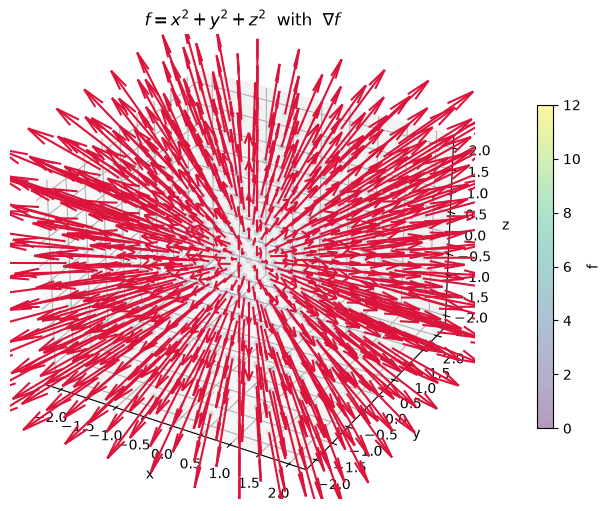

In [3]:
fig = viz.plot_gradient_3d(
    X, Y, Z, df_dx, df_dy, df_dz, f=f,
    title=r"$f = x^2+y^2+z^2$  with  $\nabla f$",
    n_arrows=5,
)
plt.show()


**Reading this.** The scatter points are colored by $f$ (darker/brighter
near the center vs. the corners), and every arrow points straight away from
the origin — exactly the "steepest ascent" behavior from notebook 01, just
no longer confined to a plane. Arrows get longer toward the corners of the
cube, where the bowl is steeper.

## 2. Divergence — a radial vector field

$F(x,y,z) = (x,y,z)$ is uniform outward flow — every point moves directly
away from the origin, faster the further out you go. Its divergence is the
constant $3$ everywhere (compare to the 2D radial source in notebook 02,
which had divergence $2$ — one more dimension to flow into raises it by
one).

div(F) — min: 3.000, max: 3.000 (analytical: 3.0 everywhere)


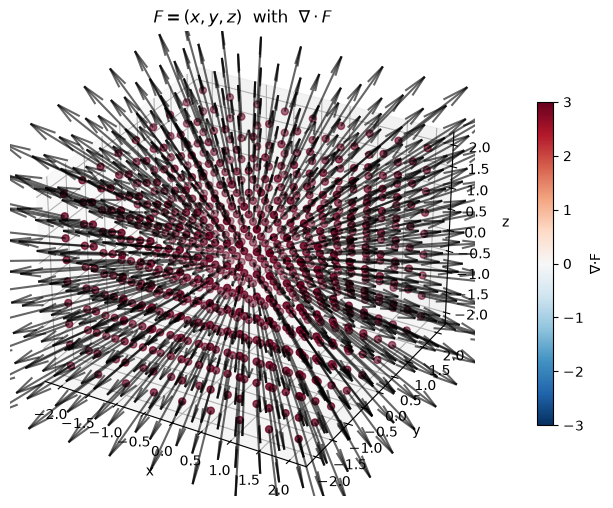

In [4]:
Fx, Fy, Fz = X, Y, Z
div = ops.divergence_3d(Fx, Fy, Fz, dx, dy, dz)

print(f"div(F) — min: {div.min():.3f}, max: {div.max():.3f} (analytical: 3.0 everywhere)")

fig = viz.plot_divergence_3d(
    X, Y, Z, Fx, Fy, Fz, div,
    title=r"$F=(x,y,z)$  with  $\nabla\cdot F$",
    n_arrows=5,
)
plt.show()


**Reading this.** The colored points are flat at the same shade (near
$3$) everywhere except right at the domain boundary, where one-sided
differences bias the estimate slightly — the same edge effect called out
in notebook 06. There's no analog of a 2D streamplot in 3D matplotlib, so
the arrows show the raw flow instead of streamlines; even so it's clear
every arrow points outward, uniformly, with no swirl.

## 3. Curl — a rotation field

$F(x,y,z) = (-y, x, 0)$ spins around the $z$-axis, same as the 2D curl
example in notebook 03, just embedded in 3D. `curl_3d` should recover
$\nabla\times F = (0,0,2)$ — a constant vector pointing along $+z$, the
axis of rotation.

curl(F) — mean: (0.000, 0.000, 2.000) (analytical: (0, 0, 2))


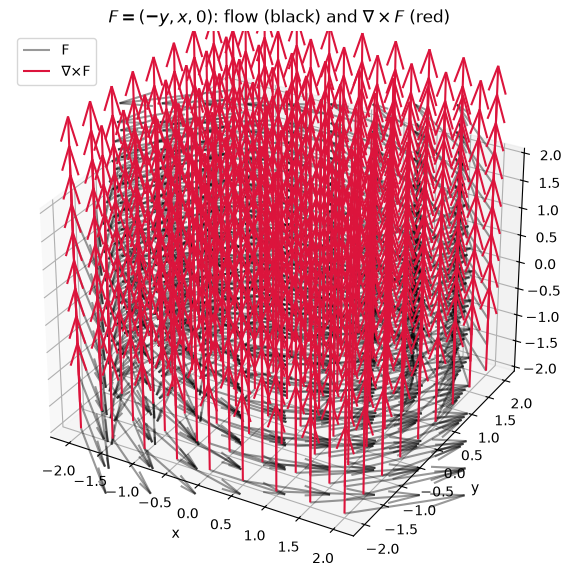

In [5]:
Fx, Fy, Fz = -Y, X, np.zeros_like(Z)
curl_x, curl_y, curl_z = ops.curl_3d(Fx, Fy, Fz, dx, dy, dz)

print(f"curl(F) — mean: ({curl_x.mean():.3f}, {curl_y.mean():.3f}, {curl_z.mean():.3f}) (analytical: (0, 0, 2))")

fig = viz.plot_curl_3d(
    X, Y, Z, Fx, Fy, Fz, curl_x, curl_y, curl_z,
    title=r"$F=(-y,x,0)$: flow (black) and $\nabla\times F$ (red)",
    n_arrows=5,
)
plt.show()


**Reading this.** The black arrows trace out the spin — circles around
the $z$-axis, same shape at every height. The red arrows are the curl
vector: constant, all pointing straight up along $+z$, the axis a
paddlewheel dropped anywhere in this field would spin around. This is the
picture the right-hand rule in notebook 03's formula is describing.

## 4. Exercise

Build $F(x,y,z) = (-y, x, 0.4z)$ — the same rotation as above, but now
with an added upward flow along $z$ (think: a tornado, not a flat spinning
disk). Compute `divergence_3d` and `curl_3d` for this field and predict,
before running anything, whether the curl changes from the pure-rotation
case above. (Hint: does the new $0.4z$ term depend on $x$ or $y$ — the only
variables curl's $z$-component differentiates with respect to?) Then check
whether the divergence is still zero.

In [6]:
# Your answer here.
# Fx, Fy, Fz = -Y, X, 0.4 * Z
# ...
